## Runging a simple case (For single GPU/CPU verison).
The easiest way to run pyquake3d is to run the single CPU version of Pyquake3D, without installing cupy.**Here we provide a asperity pathch earthquake simulation with low resolution, with initial paremeters being imported by a external file.**

1. Read model and mesh parameter(Please refer to mannul for specific meanning).
2. Calculating Green functions.
3. Calculating Qusi-Dynamic model.
4. Visualize the results.

You can also run the BP5-QD example case in the terminal:

python src/main_mpi.py -g examples/BP5-QD/bp5t.msh -p examples/BP5-QD/parameter.txt

## Initial: Import all sub-functions and libraries


In [1]:
#Let runing PyQuake3D
#First Import all sub-functions

import pyquake3d.readmsh as readmsh
import numpy as np
import sys
import matplotlib.pyplot as plt
import pyquake3d.QDsim_gpu as QDsim_gpu
from math import *
import time
import argparse
import os
import psutil
from datetime import datetime
process = psutil.Process(os.getpid())



# ----------------------------------------------------------------------------
# PyQuake3D: Boundary Element Method to simulate sequences of earthquakes and aseismic slips
# * 3D non-planar quasi-dynamic earthquake cycle simulations
# * Support for Hierarchical matrix compressed storage and calculation
# * Parallelized with MPI
# * Support for rate-and-state aging friction laws
# * Supports output to VTU formats
# * ----------------------------------------------------------------------------


## Step 1: read the model file, parameter file, and create a basic class
We prepared the msh file and parameter.txt

In [2]:


fnamegeo='BP5_circle/asperity_circle.msh'
fnamePara='BP5_circle/parameter.txt'
nodelst,elelst=readmsh.read_mshV2(fnamegeo)



## Create mesh model through Gmesh
You can create your own mesh model through Gmesh, download from https://gmsh.info/ . You can download the latest version, but remember to use version 2 when exporting mesh model.
First you need to prepare .geo file, and open it using Gmesh and it automatically mesh the domain.Then expot .msh file by File->export->Input bp5t.msh->Version 2 ASCII).

A simple asperity_circle.geo format and notes are as follows:

In [14]:
'''
// Parameters
angle = 25;   // Dip angle of the fault in degrees
Len = 50;    // Fault length along x-axis
width = 50;   // Fault width along z-axis
lc = 1.2;     // Characteristic length for mesh cell size

// Define points for the rectangular fault plane
Point(1) = {-Len/2, 0, 0, lc};   // Bottom-left corner (A)
Point(2) = {Len/2, 0, 0, lc};    // Bottom-right corner (B)
Point(3) = {Len/2, 0, -width, lc}; // Top-right corner (C)
Point(4) = {-Len/2, 0, -width, lc}; // Top-left corner (D)
// Alternative points for a dipping fault (commented out)
//Point(3) = {Len/2, width * Cos(angle * Pi / 180), -width * Sin(angle * Pi / 180), lc};
//Point(4) = {-Len/2, width * Cos(angle * Pi / 180), -width * Sin(angle * Pi / 180), lc};

// Define lines connecting the points
Line(1) = {1, 2}; // Line from A to B (bottom edge)
Line(2) = {2, 3}; // Line from B to C (right edge)
Line(3) = {3, 4}; // Line from C to D (top edge)
Line(4) = {4, 1}; // Line from D to A (left edge)

// Define the surface by creating a line loop and plane
Line Loop(1) = {1, 2, 3, 4}; // Closed loop of lines A-B-C-D
Plane Surface(1) = {1};      // Create a planar surface from the line loop

// Mesh generation settings
//Mesh.Algorithm = 1;          // Mesh algorithm: 1 = Delaunay triangulation (triangular mesh)
//Mesh.Algorithm = 8;        // Alternative: 8 = Structured quadrilateral mesh (uncomment for quads)
//Mesh.ElementOrder = 1;       // Use first-order elements (linear triangles or quads)
//Mesh.RecombineAll = 1;       // Recombine triangles into quadrilaterals (enable for quad mesh)

// Generate the 2D mesh
Mesh 2;

// Save the mesh to a file
Mesh.Format = 2;             // Output format: 1 = MSH1 format (Gmsh legacy format)
//Save "fault_mesh.msh";       // Save the mesh as fault_mesh.msh
'''

'\n// Parameters\nangle = 25;   // Dip angle of the fault in degrees\nLen = 50;    // Fault length along x-axis\nwidth = 50;   // Fault width along z-axis\nlc = 1.2;     // Characteristic length for mesh cell size\n\n// Define points for the rectangular fault plane\nPoint(1) = {-Len/2, 0, 0, lc};   // Bottom-left corner (A)\nPoint(2) = {Len/2, 0, 0, lc};    // Bottom-right corner (B)\nPoint(3) = {Len/2, 0, -width, lc}; // Top-right corner (C)\nPoint(4) = {-Len/2, 0, -width, lc}; // Top-left corner (D)\n// Alternative points for a dipping fault (commented out)\n//Point(3) = {Len/2, width * Cos(angle * Pi / 180), -width * Sin(angle * Pi / 180), lc};\n//Point(4) = {-Len/2, width * Cos(angle * Pi / 180), -width * Sin(angle * Pi / 180), lc};\n\n// Define lines connecting the points\nLine(1) = {1, 2}; // Line from A to B (bottom edge)\nLine(2) = {2, 3}; // Line from B to C (right edge)\nLine(3) = {3, 4}; // Line from C to D (top edge)\nLine(4) = {4, 1}; // Line from D to A (left edge)\n\n// 

## Create parameter and external input file

The parameter.txt file serves as a configuration file for the simulation, defining all necessary parameters to control the execution of the model. It organizes input data into distinct sections for clarity and modularity, including:

1. **Files and Cells**: Specifies file paths and mesh cell size settings.

2. **Property:** Defines material properties of the fault, such as elastic moduli or density.

3. **Fluid:** Configures fluid-related parameters, like Dilatancy coefficient or pore pressure.

4. **Stress:** Sets stress conditions applied to the fault, such as normal or shear stress.

5. **Friction:** Describes frictional properties, including friction coefficients or laws.

6. **Nucleation:** Defines parameters for initiating fault slip, such as nucleation zone size or critical stress.

7. **Output:** Configures output settings, including data formats and variables to save.

If external data is imported as the initial model, just set **InputHetoparamter: True**, and stress and friction parameters can be ignored.

**Note:** Please refer to the code (https://github.com/Computational-Geophysics/PyQuake3D/blob/main/PyQuake3D_User_Manual.pdf) manual for a detailed explanation of each parameter. The order of all parameters in parameter.txt can be arbitrarily disrupted, but the parameter names must remain strictly unchanged.

A simple way is to determine the distribution of heterogenrous parameters by the grid center coordinates. The following is an example of a code to generate an initial model

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from math import *
import os
from matplotlib.colors import ListedColormap
import pyquake3d.readmsh as readmsh
plt.rcParams.update({'font.size': 16})

pi=3.1415926


fnamegeo='BP5_circle/asperity_circle.msh'
jud_ele_order=False
nodelst,elelst=readmsh.read_mshV2(fnamegeo)
eleVec,xg=readmsh.get_eleVec(nodelst,elelst,jud_ele_order)

alst=np.zeros(eleVec.shape[0])
blst=np.zeros(eleVec.shape[0])

angle=0.0*np.pi/180.0
f0=0.6
slipv=1e-9
V0=1e-6
slipvC=1.1e-9
Dc=0.1
Tn=40
Tt=14.0/25*40

target_point=0,0,-25000

distances = np.sqrt(np.sum((xg - target_point) ** 2, axis=1))

Ds=18000
avs=0.04
bvs=0.03
avw=0.01
bvw=0.03

for i in range(len(alst)):
    #tem=min(self.xg[i,0]-xmin,xmax-self.xg[i,0],self.xg[i,2]-zmin,zmax-self.xg[i,2],Wedge)/Wedge
    coords1=np.array([xg[i]])
    dis=distances[i]/Ds
    if(dis<0.7):
        alst[i]=avw
        blst[i]=bvw
        
    elif(dis<1.0):
        
        dis1=(dis-0.7)/0.3
        alst[i]=avs-(avs-avw)*(1.0-dis1)
        blst[i]=bvs
    
    else:
        alst[i]=avs
        blst[i]=bvs

print(len(xg))
f=open('BP5_circle/Init_circle_asp.dat','w')
for i in range(len(xg)):
    f.write('0.0 %f %f %f %f %f %f 1.1e-9 0.0 0.0 0.0\n' %(alst[i],blst[i],Dc,f0,Tt,Tn))
f.close()

4126


## Visualize mesh model using PyQuake3D

All initial parameters are easily accessible through class member variables.

No Dilatancy parameters or incomplete parameters.
No thermal parameters or incomplete parameters.
Cs 3464.0
First Lamé constants 32038120320.0
Shear Modulus 32038120320.0
Youngs Modulus 80095300800.0
Poissons ratio 0.25
[40. 40. 40. ... 40. 40. 40.]
L: 0.1
maximum element size 1579.2446135826594
average elesize 1204.8529192305502
Critical nucleation size 9436.005321762927
Cohesive zone: 2359.0013304407316
UnstructuredGrid (0x21fc597dba0)
  N Cells:    4126
  N Points:   2148
  X Bounds:   -2.500e+04, 2.500e+04
  Y Bounds:   0.000e+00, 0.000e+00
  Z Bounds:   -5.000e+04, 0.000e+00
  N Arrays:   18
pyvista DataSetAttributes
Association     : CELL
Active Scalars  : Normal_[MPa]
Active Vectors  : None
Active Texture  : None
Active Normals  : None
Contains arrays :
    Normal_[MPa]            float32    (4126,)              SCALARS
    Pore_pressure[MPa]      float32    (4126,)
    Shear_[MPa]             float32    (4126,)
    Shear_1[MPa]            float32    (4126,)
    Shear_2[MPa]    

D:\Anaconda3\envs\PyQuake312\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


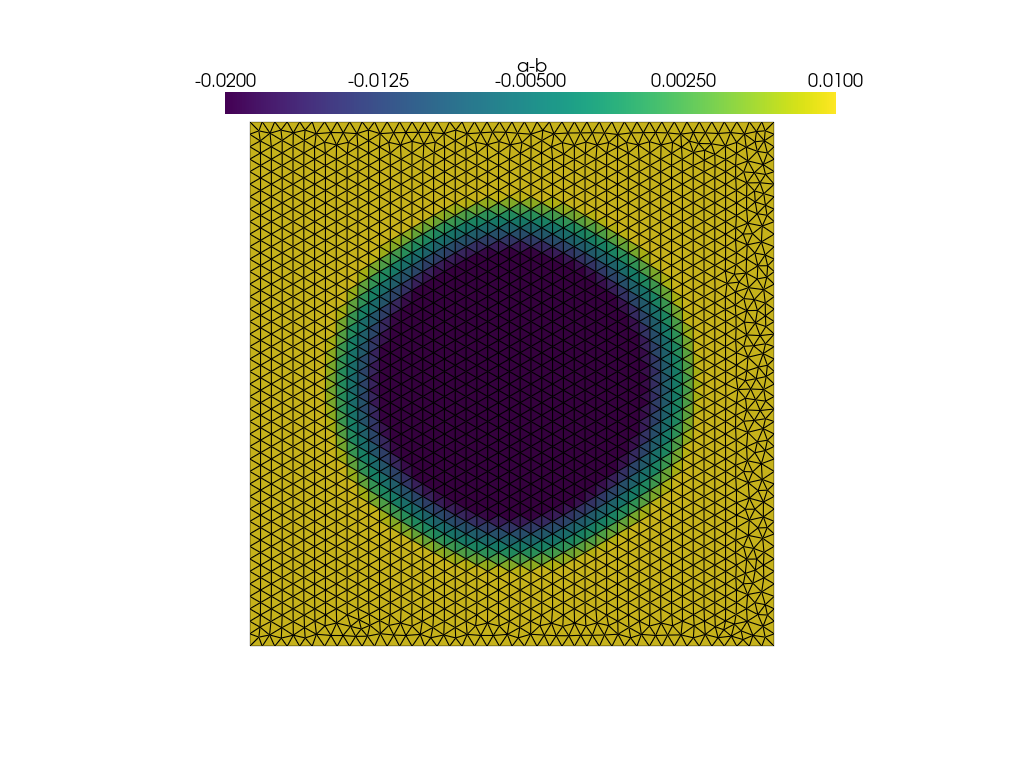

In [6]:
#Establish the initial model and generate simulation class
sim0=QDsim_gpu.QDsim(elelst,nodelst,fnamePara,calc_greenfunc=False)
#Ouput initial state
fname='Init.vtk'
sim0.ouputVTK(fname)

import pyvista as pv
plotter = pv.Plotter(off_screen=True)
mesh = pv.read(fname)

print(mesh)
print(mesh.cell_data)

variab = 'a-b' #choose the arrays to display


scalar_bar_args={
        'title': variab,
        'position_x': 0.22, 
        'position_y': 0.85,  
    }
plotter.add_mesh(mesh, scalars=variab, show_edges=True,scalar_bar_args=scalar_bar_args)  # show shear stress

plotter.show(cpos='xz')

## Step 2:  calculate greenfunctions,we encapsulate all calculations in a class QDsim
The Green function calculation is saved in the Corefunc directory defined in parameter.txt. The next time you start the program, you no longer need to calculate the Green function.

In [8]:
#Then it start to calculate greenfunctions,We encapsulate all calculations in a class QDsim
sim0=QDsim_gpu.QDsim(elelst,nodelst,fnamePara,calc_greenfunc=True)

No Dilatancy parameters or incomplete parameters.
No thermal parameters or incomplete parameters.
Cs 3464.0
First Lamé constants 32038120320.0
Shear Modulus 32038120320.0
Youngs Modulus 80095300800.0
Poissons ratio 0.25
[40. 40. 40. ... 40. 40. 40.]
L: 0.1
maximum element size 1579.2446135826594
average elesize 1204.8529192305502
Critical nucleation size 9436.005321762927
Cohesive zone: 2359.0013304407316
Start to calculate core functions...
Core functions computation completed


## Step 3:  Calculating Qusi-Dynamic model by loop

In [9]:


start_time=time.time()
    
totaloutputsteps=int(sim0.Para0['totaloutputsteps'])
directory='outvtk'
if not os.path.exists(directory):
    os.mkdir(directory)

f=open('state.txt','w')
f.write('iteration time_step(s) maximum_slip1_rate(m/s) maximum_slip2_rate(m/s) time(s) time(h)\n')

if(sim0.useGPU==False):  #CPU case
    for i in range(totaloutputsteps): 
        

        if(i==0):
            dttry=sim0.htry
        else:
            dttry=dtnext
        dttry,dtnext=sim0.simu_forward(dttry)
        year=sim0.time/3600/24/365
        if(i%10==0):
            print('iteration:',i)
            print('dt:',dttry,' max_vel:',np.max(np.abs(sim0.slipv)),' Seconds:',sim0.time,'  Days:',sim0.time/3600/24,
                'year',year)
            memory_info = process.memory_info()
            print(f"Memory usage: {memory_info.rss / (1024 ** 2)} MB")
        f.write('%d %f %.16e %.16e %f %f\n' %(i,dttry,np.max(np.abs(sim0.slipv1)),np.max(np.abs(sim0.slipv2)),sim0.time,sim0.time/3600.0/24.0))

        
        
        if(sim0.Para0['outputvtk']=='True'):
            outsteps=int(sim0.Para0['outsteps']) #output steps
            if(i%outsteps==0):
                fname=directory+'/step'+str(i)+'.vtk'
                sim0.ouputVTK(fname)

end_time = time.time()
timetake=end_time-start_time
f.write('Program end time: %s\n'%str(datetime.now()))
f.write("Time taken: %.2f seconds\n"%timetake)

print('Program end time: %s\n'%str(datetime.now()))
print("Time taken: %.2f seconds\n"%timetake)

iteration: 0
dt: 0.001  max_vel: 1.1000000000031157e-09  Seconds: 0.001   Days: 1.1574074074074074e-08 year 3.1709791983764586e-11
Memory usage: 1144.93359375 MB
iteration: 10
dt: 0.057665039062500006  max_vel: 1.1000000005326008e-09  Seconds: 0.17099511718750002   Days: 1.9791101526331023e-06 year 5.422219596255075e-09
Memory usage: 1144.97265625 MB
iteration: 20
dt: 3.3252567300796505  max_vel: 1.1000000310670171e-09  Seconds: 9.973770190238952   Days: 0.00011543715497961749 year 3.162661780263493e-07
Memory usage: 1144.97265625 MB
iteration: 30
dt: 191.75105923288402  max_vel: 1.1000017918474052e-09  Seconds: 575.2511776986521   Days: 0.006657999741882547 year 1.8241095183239854e-05
Memory usage: 1144.9765625 MB
iteration: 40
dt: 11057.332320940008  max_vel: 1.1001033708756344e-09  Seconds: 33171.99496282003   Days: 0.38393512688449105 year 0.0010518770599575098
Memory usage: 1144.9765625 MB
iteration: 50
dt: 637621.5002140492  max_vel: 1.1061082937215117e-09  Seconds: 1912864.49864

iteration: 460
dt: 0.008705447022774319  max_vel: 0.6969474522802851  Seconds: 119899504.08861345   Days: 1387.7257417663593 year 3.801988333606464
Memory usage: 1086.50390625 MB
iteration: 470
dt: 0.008557816546666822  max_vel: 0.7203431608501796  Seconds: 119899504.1750589   Days: 1387.7257427668856 year 3.8019883363476317
Memory usage: 1086.50390625 MB
iteration: 480
dt: 0.008110855388170956  max_vel: 0.7417480198405988  Seconds: 119899504.25831364   Days: 1387.7257437304818 year 3.8019883389876212
Memory usage: 1086.50390625 MB
iteration: 490
dt: 0.007843801877962606  max_vel: 0.7602482904902677  Seconds: 119899504.33782643   Days: 1387.725744650769 year 3.8019883415089564
Memory usage: 1086.50390625 MB
Program end time: 2025-09-03 14:45:27.221627

Time taken: 15.85 seconds



## Step 4: Visualize Results

The simulation generates VTK files, visualize them using PyVista.You can also output all results in your own format by accessing the member variables of sim0(e.g. sim0.slip).

(369, 6)


D:\Anaconda3\envs\PyQuake312\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


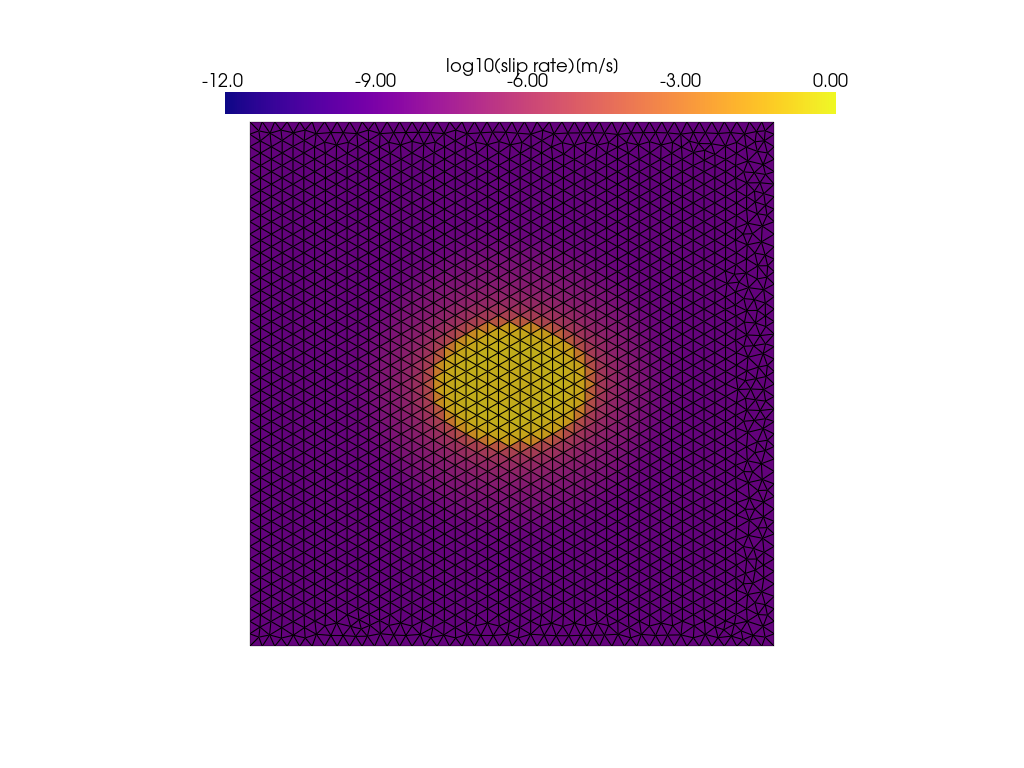

Video has been saved.


In [10]:
import pyvista as pv
import glob
import os

# set vtk file path
folder_path = "outvtk/"  

vtk_files = glob.glob(os.path.join(folder_path, "*.vtk")) + glob.glob(os.path.join(folder_path, "*.vtu"))


#read state file for time show
def is_number(s):
    try:
        float(s) 
        return True
    except ValueError:
        return False

def readstate(fname):
    f=open(fname,'r')
    K=0
    data0=[]
    for line in f:
        tem=line.split()
        
        if(len(tem)==6 and is_number(tem[0])==True):
            data0.append(np.array(tem).astype(float))
    return np.array(data0)
state=readstate('state.txt')
print(state.shape)

# # show one figure 
plotter = pv.Plotter(off_screen=True)
mesh = pv.read(vtk_files[10])
slip_velocity = mesh['Slipv[m/s]']
# Apply logarithmic transformation (e.g., base 10)
# Add small constant (e.g., 1e-10) to avoid log(0) issues
log_slip_velocity = np.log10(slip_velocity)

# Assign the transformed scalars back to the mesh
mesh['Log_Slipv[m/s]'] = log_slip_velocity
scalar_range = (-12, 0)
scalar_bar_args={
        'title': 'log10(slip rate)[m/s]',
        'position_x': 0.22, 
        'position_y': 0.85,  
    }
plotter.add_mesh(mesh, scalars='Log_Slipv[m/s]', cmap="plasma", show_edges=True,clim=scalar_range,scalar_bar_args=scalar_bar_args)  # show shear stress

#plotter.camera_position =[(0, -5, 0), (0, 0, 0), (0, 0, 1)]
# plotter.add_scalar_bar(
#         title='log10(Slip rate)[m/s]',  # Label for the colorbar
#         position_x=0.25,         # Horizontal position (0 to 1, 0.25 centers it with width=0.5)
#         position_y=0.05,         # Vertical position (close to bottom)
#         width=0.5,              # Width of the colorbar (0 to 1, relative to plot)
#         height=0.1,             # Height of the colorbar
#         vertical=False          # Horizontal orientation
#     )
plotter.show(cpos='xz')

# create animation
outsteps=int(sim0.Para0['outsteps'])
plotter = pv.Plotter(off_screen=True)
plotter.open_gif('animation.gif')  # Initialize GIF output

for i, vtk_file in enumerate(vtk_files):
    if(i*outsteps<len(state)):
        mesh = pv.read(folder_path+'step'+str(i*outsteps)+'.vtk')
        slip_velocity = mesh['Slipv[m/s]']
        # Apply logarithmic transformation (e.g., base 10)
        # Add small constant (e.g., 1e-10) to avoid log(0) issues
        log_slip_velocity = np.log10(slip_velocity)
        
        # Assign the transformed scalars back to the mesh
        mesh['Log_Slipv[m/s]'] = log_slip_velocity
        plotter.clear()  # Clear previous mesh
        plotter.add_mesh(
            mesh,
            scalars='Log_Slipv[m/s]',
            cmap="plasma",
            show_edges=False,
            clim=scalar_range,
            scalar_bar_args=scalar_bar_args
        )
        
        timeyear=state[i*outsteps,-1]/365
        plotter.add_text(f"Time: {timeyear:.8f} yr", position="upper_left", font_size=14, color="white", shadow=True)
        plotter.camera_position = 'xz'
        plotter.write_frame()  # Write frame to GIF

plotter.close()
print('Video has been saved.')


In [11]:
import cupy as cp
print(cp.cuda.is_available())  # check CUDA availble
print(cp.cuda.runtime.getDeviceCount())

True
1


## GPU case

The GPU operates in a similar way to the CPU, only the output is converted to numpy each time. Reading model and parameters is the same as CPU.

**Note**: Make sure to set GPU:True in the parameter.txt

In [12]:

start_time=time.time()
    
totaloutputsteps=int(sim0.Para0['totaloutputsteps'])
directory='outvtk'
if not os.path.exists(directory):
    os.mkdir(directory)

f=open('state.txt','w')
f.write('iteration time_step(s) maximum_slip1_rate(m/s) maximum_slip2_rate(m/s) time(s) time(h)\n')


if(sim0.useGPU==True): #GPU case
    sim0.initGPUvariable()
    
    for i in range(totaloutputsteps):
        print('iteration:',i)
        if(i==0):
            dttry=sim0.htry
        else:
            dttry=dtnext
        dttry,dtnext=sim0.simu_forwardGPU(dttry)

        #transform form cupy to numpy data
        sim0.slipv1=sim0.slipv1_gpu.get()
        sim0.slipv2=sim0.slipv2_gpu.get()
        sim0.slipv=sim0.slipv_gpu.get()
        sim0.slip=sim0.slip_gpu.get()
        sim0.Tt1o=sim0.Tt1o_gpu.get()
        sim0.Tt2o=sim0.Tt2o_gpu.get()
        sim0.Tt=sim0.Tt_gpu.get()
        #sim0.state1=sim0.state1_gpu.get()
        #sim0.state2=sim0.state2_gpu.get()
        sim0.rake=sim0.rake_gpu.get()
        year=sim0.time/3600/24/365
        if(i%10==0):
            print('dt:',dttry,' Seconds:',sim0.time,'  Days:',sim0.time/3600/24,'year',year)
            print(' max_vel1:',np.max(np.abs(sim0.slipv1)),' max_vel2:',np.max(np.abs(sim0.slipv2)),' min_Tt1:',np.min(sim0.Tt1o),' min_Tt2:',np.min(sim0.Tt2o))  
        f.write('%d %f %.16e %.16e %f %f\n' %(i,dttry,np.max(np.abs(sim0.slipv1)),np.max(np.abs(sim0.slipv2)),sim0.time,sim0.time/3600.0/24.0))

        memory_info = process.memory_info()
        print(f"Memory usage: {memory_info.rss / (1024 ** 2)} MB")

        if(sim0.Para0['outputvtk']=='True'):
            outsteps=int(sim0.Para0['outsteps'])#output steps
            if(i%outsteps==0):
                fname=directory+'/step'+str(i)+'.vtk'
                sim0.ouputVTK(fname)